In [1]:
1+2

3

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad,dblquad


In [3]:
Gfermi = 1.166379e-5
m_e = 0.0005109989461
m_mu = 0.1056583745
m_tau = 1.77686
m_piplus = 0.13957039
m_pizero = 0.1349768
m_Kplus = 0.493677
m_Klonog = 0.497611
m_top = 172.76
m_eta = 0.547862
m_rho = 0.77526
rho_width = 0.1478
m_etap = 0.95778

fsc = 7.2973525693e-3
sin2thetaW = 0.2312
gL = -0.5 + sin2thetaW
gR = sin2thetaW
absVud2 = 0.97370 * 0.97370

fpion = 0.1302
f0 = 0.148
f8 = 0.165
th0 = -6.9*np.pi/180
th8 = -21.2*np.pi/180.
feta = np.cos(th8)*f8/np.sqrt(3) + np.sin(th0)*f0/np.sqrt(6)
fetap = np.sin(th8)*f8/np.sqrt(3) - np.cos(th0)*f0/np.sqrt(6)
frho = 0.171
grho = 1 - 2*sin2thetaW



In [4]:
def width_muon(alp_mass, cB,  cW,  cG,  cAl,  fA):
    if m_mu * 2 > alp_mass: return 0
    width = (cAl*cAl * alp_mass * m_mu * m_mu)*np.sqrt(1. - 4. * m_mu*m_mu / (alp_mass*alp_mass)) / (8 * np.pi * fA*fA)
    return width

def width_e():
    return 0.

def B1(x):
    g = 0.
    if x >= 1.:
        g = np.arcsin(1./np.sqrt(x))
    else:
        g = np.pi/2. + 1j * np.log((1+np.sqrt(1-x)) / (1-np.sqrt(1-x)))/2. # JD: there was a missing factor of 1/2 next to the pi that I added. My correction matches code and is correct.
    return 1. - x*g*g

def width_gamma(alp_mass,  cB,  cW,  cG,  cAl,  fa):
    cgluon = cG*(-1.92 + # JD: changed from -1.92 to -1.93 to match what's written in TN. Update 9/30/25: 1.92 is correct and in code, and I have changed it back to 1.92 here and updated drafts from 1.93 to 1.92.
                 (1./3.)*alp_mass*alp_mass / (alp_mass*alp_mass - m_pizero*m_pizero)+ # JD: why m_pizero as opposed to m_piplus?
                 (8./9.)*(alp_mass*alp_mass - (4./9.)*m_pizero*m_pizero) / (alp_mass*alp_mass - m_eta * m_eta) +
                 (7./9.)*(alp_mass*alp_mass - (16./9.)*m_pizero*m_pizero) / (alp_mass*alp_mass - m_etap*m_etap))

    clep = 2*cAl*(B1(4*m_e*m_e / (alp_mass*alp_mass)) + # JD: removed an overall factor of 2. 
                                                        # Update 9/30/25: the code has the factor of 2. L140 here: https://github.com/SBNSoftware/sbncode/blob/develop/sbncode/EventGenerator/MeVPrtl/Tools/ALP/ALPMakeDecay_tool.cc
                                                        # what's correct: the code; the factor of 2 should be there.
                                                        # see eqn 10 in this paper: https://arxiv.org/pdf/2210.02462
                                                        # Now I have put the factor of 2 back in here, and I have updated the drafts to include the factor of 2.
                  B1(4*m_mu*m_mu / (alp_mass*alp_mass)) +
                  B1(4*m_tau*m_tau / (alp_mass*alp_mass)))

    cgamma = (5./3.)*cB + cW + cgluon + clep

    width = fsc*fsc*(abs(cgamma)**2)*alp_mass*alp_mass*alp_mass/(256*np.pi*np.pi*np.pi*fa*fa); # JD: was missing a square around abs(c_gamma) before I added it. This is correct and the code is consistent. Drafts are correct.

    return width

def AmpPiPPiMPi0(alp_mass, fa_eff, m2_pip_pim):
    deltaI = 1./3.
    fpion_p = fpion / np.sqrt(2)
    M2_pi0_pi0 = m_pizero*m_pizero
    M2_eta_pi0 = - M2_pi0_pi0*np.sqrt(2./3.)
    M2_etap_pi0 = -M2_pi0_pi0/np.sqrt(3.)
    S_eta_pi0 = M2_eta_pi0 / (m_eta*m_eta - m_pizero*m_pizero)
    S_etap_pi0 = M2_etap_pi0 / (m_etap*m_etap - m_pizero*m_pizero)

    expct_a_pi = (deltaI / 2.) * (alp_mass*alp_mass) / (alp_mass*alp_mass - m_pizero*m_pizero)
    expct_a_eta = (alp_mass*alp_mass/np.sqrt(6.) - m_pizero*m_pizero/np.sqrt(24.)) / (alp_mass*alp_mass - m_eta*m_eta);
    expct_a_etap = (alp_mass*alp_mass/np.sqrt(12.) - m_pizero*m_pizero/np.sqrt(3.)) / (alp_mass*alp_mass - m_etap*m_etap);

    return (1. / (3.*fa_eff*fpion_p))*((3*m2_pip_pim - alp_mass*alp_mass - 2*m_pizero*m_pizero)*expct_a_pi
            - deltaI*m_pizero*m_pizero*(1./np.sqrt(3.) + np.sqrt(2.)*S_eta_pi0 + S_etap_pi0)*(np.sqrt(2)*expct_a_eta + expct_a_etap)
            + deltaI*(m_pizero*m_pizero - 2*m_eta*m_eta)/(m_pizero*m_pizero-4*m_eta*m_eta)*
            (np.sqrt(3.)*m_pizero*m_pizero*(np.sqrt(2.)*S_eta_pi0 + S_etap_pi0) - 3*m2_pip_pim + alp_mass*alp_mass + 3*m_pizero*m_pizero))


def width_PiPPiMPi0(alp_mass, cB,  cW,  cG,  cAl, fa):
    kfactor = 2.7
    S = 1

    if 2*m_piplus + m_pizero >= alp_mass: return 0. # JD: changed from >= to >. update: should change back. Josh says that if it's an equality, the width should be zero anyway b/c there's no phase space for the decay. So may as well make it >= so it doesn't try to evaluate a poorly behaved integral.

    masses = [alp_mass, m_piplus, m_piplus, m_pizero]
    M122Min = pow(masses[1] + masses[2], 2.0);
    M122Max = pow(masses[0] - masses[3], 2.0);
    # this stuff comes from this place in the code: https://github.com/SBNSoftware/sbncode/blob/develop/sbncode/EventGenerator/MeVPrtl/Tools/ALP/ThreeBodyIntegrator.cc
    def GetE2st(m122):
        m1 = masses[1]
        m2 = masses[2]
        return 0.5 * (m122 - pow(m1, 2.0) + pow(m2, 2.0)) / np.sqrt(m122)

    def GetE3st(m122):
        M = masses[0]
        m3 = masses[3]
        return 0.5 * (pow(M, 2.0) - m122 - pow(m3, 2.0)) / np.sqrt(m122)

    def M232Min(m122):
        m2 = masses[2]
        m3 = masses[3]
        E2st = GetE2st(m122)
        E3st = GetE3st(m122)
        return pow(E2st + E3st, 2.0) - pow(np.sqrt(E2st*E2st - m2*m2) + np.sqrt(E3st*E3st - m3*m3), 2.0)

    def M232Max(m122):
        m2 = masses[2]
        m3 = masses[3]
        E2st = GetE2st(m122)
        E3st = GetE3st(m122)
        return pow(E2st + E3st, 2.0) - pow(np.sqrt(E2st*E2st - m2*m2) - np.sqrt(E3st*E3st - m3*m3), 2.0)

    integ_res = dblquad(lambda m232,m122 : abs(AmpPiPPiMPi0(alp_mass, fa/cG, m122))**2,M122Min,M122Max,M232Min,M232Max)[0]

    return (kfactor / (2*S*alp_mass*128*pow(np.pi,3)*alp_mass*alp_mass)) * integ_res

def AmpPi0Pi0Pi0(alp_mass, fa_eff):
    deltaI = 1./3.
    fpion_p = fpion / np.sqrt(2)

    M2_pi0_pi0 = m_pizero*m_pizero
    M2_eta_pi0 = - M2_pi0_pi0*np.sqrt(2./3.)
    M2_etap_pi0 = -M2_pi0_pi0/np.sqrt(3.)
    S_eta_pi0 = M2_eta_pi0 / (m_eta*m_eta - m_pizero*m_pizero)
    S_etap_pi0 = M2_etap_pi0 / (m_etap*m_etap - m_pizero*m_pizero)

    expct_a_pi = (deltaI / 2.) * (alp_mass*alp_mass) / (alp_mass*alp_mass - m_pizero*m_pizero)
    expct_a_eta = (alp_mass*alp_mass/np.sqrt(6.) - m_pizero*m_pizero/np.sqrt(24.)) / (alp_mass*alp_mass - m_eta*m_eta)
    expct_a_etap = (alp_mass*alp_mass/np.sqrt(12.) - m_pizero*m_pizero/np.sqrt(3.)) / (alp_mass*alp_mass - m_etap*m_etap)

    res = expct_a_pi - deltaI*(1./np.sqrt(3) + np.sqrt(2)*S_eta_pi0 + S_etap_pi0)*(np.sqrt(2.)*expct_a_eta + expct_a_etap)
    res = res + np.sqrt(3)*deltaI*((m_pizero*m_pizero - 2*m_eta*m_eta) / (m_pizero*m_pizero - 4*m_eta*m_eta))*(np.sqrt(2)*S_eta_pi0 + S_etap_pi0) # JD: added last product. L211 in code. My change is correct and consistent with code. Drafts are correct.
    #res = res + (np.sqrt(2.)*S_eta_pi0 + S_etap_pi0) # JD: commented out
    res = res * (m_pizero*m_pizero / (fa_eff*fpion))
    return res

def width_Pi0Pi0Pi0(alp_mass, cB,  cW,  cG,  cAl,  fa):
    kfactor = 2.7
    S = 6

    if 3*m_pizero >= alp_mass: return 0. 

    masses = [alp_mass, m_pizero, m_pizero, m_pizero]
    M122Min = pow(masses[1] + masses[2], 2.0);
    M122Max = pow(masses[0] - masses[3], 2.0);
    def GetE2st(m122):
        m1 = masses[1]
        m2 = masses[2]
        return 0.5 * (m122 - pow(m1, 2.0) + pow(m2, 2.0)) / np.sqrt(m122)

    def GetE3st(m122):
        M = masses[0]
        m3 = masses[3]
        return 0.5 * (pow(M, 2.0) - m122 - pow(m3, 2.0)) / np.sqrt(m122)

    def M232Min(m122):
        m2 = masses[2]
        m3 = masses[3]
        E2st = GetE2st(m122)
        E3st = GetE3st(m122)
        return pow(E2st + E3st, 2.0) - pow(np.sqrt(E2st*E2st - m2*m2) + np.sqrt(E3st*E3st - m3*m3), 2.0)

    def M232Max(m122):
        m2 = masses[2]
        m3 = masses[3]
        E2st = GetE2st(m122)
        E3st = GetE3st(m122)
        return pow(E2st + E3st, 2.0) - pow(np.sqrt(E2st*E2st - m2*m2) - np.sqrt(E3st*E3st - m3*m3), 2.0)

    integ_res = dblquad(lambda m232,m122 : abs(AmpPi0Pi0Pi0(alp_mass, fa/cG))**2,M122Min,M122Max,M232Min,M232Max)[0]
    return (kfactor / (2*S*alp_mass*128*pow(np.pi,3)*alp_mass*alp_mass)) * integ_res

def GS_BW_betapi(s):
    pimass = m_piplus

    return np.sqrt(1 - 4.*pimass*pimass / s);

def GS_BW_k(s):
    return (1./2.)*np.sqrt(s)*GS_BW_betapi(s)

def GS_BW_d(m):
    pimass = m_piplus
    kval = GS_BW_k(m*m)

    return (3/np.pi)*(pimass*pimass/(kval*kval))*np.log((m+2*kval)/(2*pimass)) + m/(2*np.pi*kval) - pimass*pimass*m/(np.pi*kval*kval*kval);

def GS_BW_h(s):
    pimass = m_piplus

    return (2./np.pi)*(GS_BW_k(s)/np.sqrt(s))*np.log((np.sqrt(s) + 2*GS_BW_k(s)) / (2*pimass))

def GS_BW_hprime(s):
    pimass = m_piplus

    return (1./(2*np.pi*s)) + (2*pimass*pimass / (np.pi*s*s*GS_BW_betapi(s))) * np.log((1+GS_BW_betapi(s))*np.sqrt(s)/(2*pimass));

def GS_BW_Gamma(s, m, G):
    beta_frac = GS_BW_betapi(s) / GS_BW_betapi(m*m)
    return G*(s/(m*m))*beta_frac*beta_frac*beta_frac


def GS_BW_f(s,m,G):
    kval_s = GS_BW_k(s)
    kval_m2 = GS_BW_k(m*m)
    hval_s = GS_BW_h(s)
    hval_m2 = GS_BW_h(m*m)
    hpval = GS_BW_hprime(m*m)

    return (G*m*m/(kval_m2*kval_m2*kval_m2))*(kval_s*kval_s*(hval_s-hval_m2) + (m*m-s)*kval_m2*kval_m2*hpval);

def RhoBreitWeitner(s):
    return (1. + GS_BW_d(m_rho) * rho_width / m_rho) / (m_rho*m_rho - s + GS_BW_f(s, m_rho, rho_width) - 1j*m_rho*GS_BW_Gamma(s, m_rho, rho_width))

def width_PiPPiMGamma(alp_mass, cB,  cW,  cG,  cAl,  fa, a_is_etap=False):
    #JD Question: The TN doesn't assign any sign (or zeros) to the pions for this channel. Does it only apply for charged pions, but not for neutral pions?
    # answer: the code only has piPpiM (no neutral pion version), which is correct due to the isospin structure. (See reference.) 
    # I have now indicated in the drafts that this channel is for charged pions only.
    alpha_em = fsc

    if 2*m_piplus >= alp_mass: return 0. 
    fa_eff = fa/cG # JD: why?? Answer: there is a factor of cG in fa in Aloni paper. Doesn't matter if cg=1. It is correct that the fa should have some dependence on one of the couplings. 
                    # We SHOULD have this dependence everywhere or nowhere - make sure that it is used the same in all the widths. Josh says he thinks it's all consistent in code, just sometimes written in a clunky way: sometimes fa_eff is written in, sometimes fa/cg is written in. Shouldn't give any physics errors.

    m2pipi_min = 4*m_piplus*m_piplus
    m2pipi_max = alp_mass*alp_mass

    expct_a_eta =  0. if a_is_etap else (alp_mass*alp_mass/np.sqrt(6.) - m_pizero*m_pizero/np.sqrt(24.)) / (alp_mass*alp_mass - m_eta*m_eta)
    expct_a_etap = 1. if a_is_etap else (alp_mass*alp_mass/np.sqrt(12.) - m_pizero*m_pizero/np.sqrt(3.)) / (alp_mass*alp_mass - m_etap*m_etap)

    def PiPPiMGammaIntegrand(m2pipi, alp_mass, expct_a_eta, expct_a_etap):
        g2 = 12*np.pi

        arhorho = expct_a_eta/np.sqrt(6) + expct_a_etap/np.sqrt(12)
        BW2 = abs(RhoBreitWeitner(m2pipi))

        return g2*g2*m2pipi*BW2*BW2*arhorho*arhorho*pow((1-m2pipi/(alp_mass*alp_mass)), 3)*pow(1-4*m_piplus*m_piplus/m2pipi, 3./2.) 
        # JD: changed from 2 to 1 factor of alp_mass in denominator of cubed term. Update 9/30/25: code has two factors of alp_mass. What's correct: the code. I've added it back here, and updated it in the drafts.
        # JD: Changed from 1 to 2 factors of BW2. Correct and matches code. Drafts are also correct.
    integral = quad(lambda m2pipi : PiPPiMGammaIntegrand(m2pipi,alp_mass,expct_a_eta,expct_a_etap),m2pipi_min,m2pipi_max)[0]
    prefactor = 3*alpha_em*alp_mass*alp_mass*alp_mass / (2048*pow(np.pi, 6)*fa_eff*fa_eff) # JD: why not just fa?

    return integral*prefactor

widths = {r'$\gamma\gamma$' : width_gamma,
          r'$\pi^+\pi^-\pi^0$' : width_PiPPiMPi0, # JD: fixed a typo in the label.
          r'$3\pi^0$' : width_Pi0Pi0Pi0,\
          r'$\pi^+\pi^-\gamma$' : width_PiPPiMGamma,
          r'$\mu\mu$' : width_muon}

def total_width(ma, cB,  cW, cAl):
    return sum([widths[channel](ma, cB,  cW,  1.0,  cAl, 1.0e5) for channel in widths])

def br(channel,ma, cB,  cW, cAl):
    total = total_width(ma, cB,  cW, cAl)
    return widths[channel](ma, cB,  cW, 1.0, cAl, 1.0e5) / total



In [5]:
brs_equal = {}
brs_cGonly = {}
brs_dfsz = {}
brs_muon = {}
brs_MeVPrtl_default = {}

ma_list = np.linspace(0.00125,0.9,500)
for channel in widths:
    this_br = [br(channel,ma,1.0,1.0,0.0) for ma in ma_list]
    if np.any(this_br):
        brs_equal[channel] = this_br
    this_br = [br(channel,ma,0.0,0.0,0.0) for ma in ma_list]
    if np.any(this_br):
        brs_cGonly[channel] = this_br
    this_br = [br(channel,ma,8./3.,8./3.,0.0) for ma in ma_list]
    if np.any(this_br):
        brs_dfsz[channel] = this_br
    this_br = [br(channel,ma,1.0,1.0,1.0/100) for ma in ma_list]
    if np.any(this_br):
        brs_muon[channel] = this_br
    



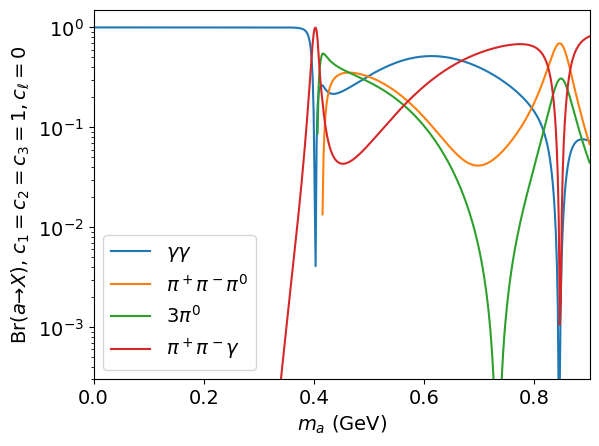

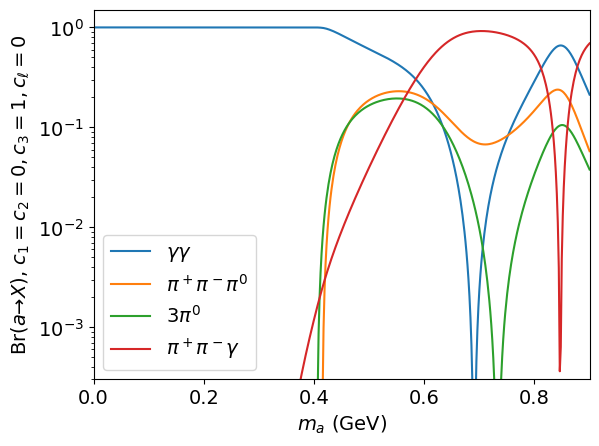

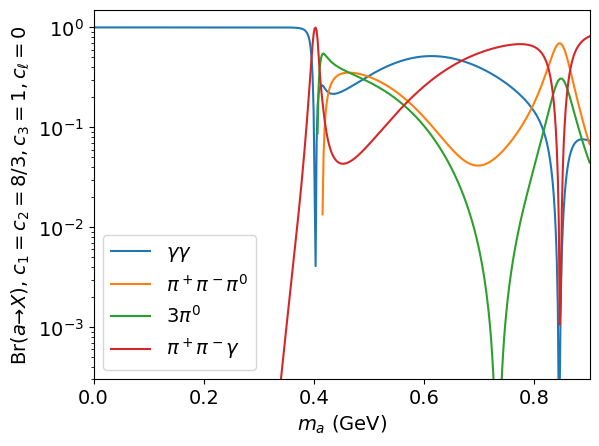

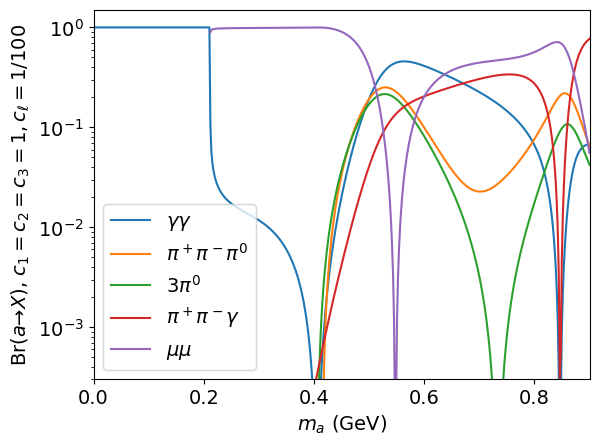

In [6]:
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 14
for channel in brs_equal:
    plt.plot(ma_list,[br if br > 0 else np.nan for br in brs_equal[channel]],label=channel)
plt.yscale('log')
plt.xlim([0,0.9])
plt.ylim([3e-4,1.5])
plt.xlabel('$m_a$ (GeV)')
plt.ylabel('Br($a \u2192 X$), $c_1 = c_2 = c_3 = 1, c_\ell = 0$')
plt.legend()
plt.savefig('br_alp_equal.pdf',bbox_inches = 'tight', dpi=300)
plt.show()

plt.clf()
plt.cla()
for channel in brs_cGonly:
    plt.plot(ma_list,[br if br > 0 else np.nan for br in brs_cGonly[channel]],label=channel)
plt.yscale('log')
plt.xlim([0,0.9])
plt.ylim([3e-4,1.5])
plt.xlabel('$m_a$ (GeV)')
plt.ylabel('Br($a \u2192 X$), $c_1 = c_2 = 0, c_3 = 1, c_\ell = 0$')
plt.legend()
plt.savefig('br_alp_cGonly.pdf',bbox_inches = 'tight', dpi=300)
plt.show()

plt.clf()
plt.cla()
for channel in brs_dfsz:
    plt.plot(ma_list,[br if br > 0 else np.nan for br in brs_equal[channel]],label=channel)
plt.yscale('log')
plt.xlim([0,0.9])
plt.ylim([3e-4,1.5])
plt.xlabel('$m_a$ (GeV)')
plt.ylabel('Br($a \u2192 X$), $c_1 = c_2 = 8/3, c_3 = 1, c_\ell = 0$')
plt.legend()
plt.savefig('br_alp_dfsz.pdf',bbox_inches = 'tight', dpi=300)
plt.show()

plt.clf()
plt.cla()
for channel in brs_muon:
    plt.plot(ma_list,[br if br > 0 else np.nan for br in brs_muon[channel]],label=channel)
plt.yscale('log')
plt.xlim([0,0.9])
plt.ylim([3e-4,1.5])
plt.xlabel('$m_a$ (GeV)')
plt.ylabel('Br($a \u2192 X$), $c_1 = c_2 = c_3 = 1, c_\ell = 1/100$')
plt.legend()
plt.savefig('br_alp_muon.pdf',bbox_inches = 'tight', dpi=300)
plt.show()



### Widths:
Look at widths for comparison with https://arxiv.org/pdf/2210.02462 Fig. 2.

In [18]:
def width_3pi(alp_mass, cB,  cW,  cG,  cAl,  fa):
    return width_Pi0Pi0Pi0(alp_mass, cB,  cW,  cG,  cAl,  fa)+width_PiPPiMPi0(alp_mass, cB,  cW,  cG,  cAl,  fa)
def total_width(ma, cB,  cW, cG,  cAl, fa):
    return sum([widths[channel](ma, cB,  cW, cG, cAl, fa) for channel in widths])

widths = {r'$\gamma\gamma$' : width_gamma,
          r'$3\pi$' : width_3pi,
          r'$\pi^+\pi^-\gamma$' : width_PiPPiMGamma,
          r'$\mu\mu$' : width_muon}

#(alp_mass, cB,  cW,  cG,  cAl,  fa, a_is_etap=False)
ma_list = np.linspace(0.00125,1.6,400) # NOTE: missing the pipieta at high masses.


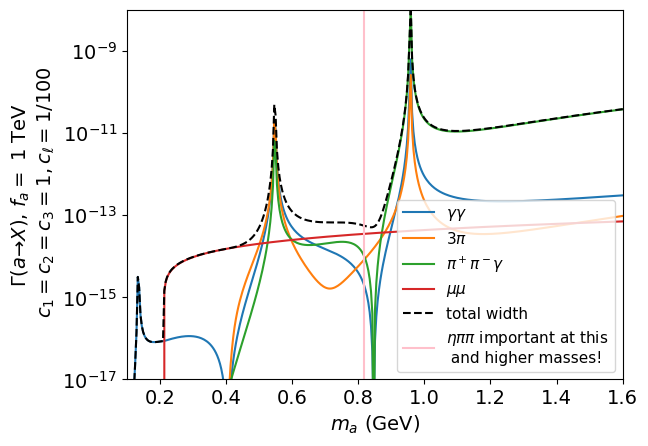

In [20]:
for channel in widths:
    plt.plot(ma_list, [widths[channel](ma,1.0,1.0,1.0,1.0/100, 1.0e3) for ma in ma_list],label=channel)
plt.plot(ma_list, [total_width(ma,1.0,1.0,1.0,1.0/100, 1.0e3) for ma in ma_list],label='total width', color='black', linestyle='--')
plt.yscale('log')
plt.xlim([0.1, 1.6])
plt.ylim([1e-17,1e-8])
plt.xlabel('$m_a$ (GeV)')
plt.ylabel('$\Gamma(a \u2192 X$), $f_a=$ 1 TeV \n $c_1 = c_2 = c_3 = 1, c_\ell = 1/100$')
plt.axvline([m_pizero+m_pizero+m_eta], label='$\eta\pi\pi$ important at this \n and higher masses!', color='pink')
plt.legend(loc='lower right', fontsize=11)
plt.savefig('widths_alp_muon.pdf',bbox_inches = 'tight', dpi=300)
plt.show()